In [1]:
import torch
import torch.nn as nn
import os
import torch.nn.functional as F
import torch.optim as optim

torch.manual_seed(1)

In [2]:
lstm = nn.LSTM(3, 3)  # Input dim is 3, output dim is 3
inputs = [torch.randn(1, 3) for _ in range(5)]  # make a sequence of length 5

# initialize the hidden state.
hidden = (torch.randn(1, 1, 3),
          torch.randn(1, 1, 3))
for i in inputs:
    # Step through the sequence one element at a time.
    # after each step, hidden contains the hidden state.
    out, hidden = lstm(i.view(1, 1, -1), hidden)

# alternatively, we can do the entire sequence all at once.
# the first value returned by LSTM is all of the hidden states throughout
# the sequence. the second is just the most recent hidden state
# (compare the last slice of "out" with "hidden" below, they are the same)
# The reason for this is that:
# "out" will give you access to all hidden states in the sequence
# "hidden" will allow you to continue the sequence and backpropagate,
# by passing it as an argument  to the lstm at a later time
# Add the extra 2nd dimension
inputs = torch.cat(inputs).view(len(inputs), 1, -1)
hidden = (torch.randn(1, 1, 3), torch.randn(1, 1, 3))  # clean out hidden state
out, hidden = lstm(inputs, hidden)
print(out)
print(hidden)

tensor([[[-0.0187,  0.1713, -0.2944]],

        [[-0.3521,  0.1026, -0.2971]],

        [[-0.3191,  0.0781, -0.1957]],

        [[-0.1634,  0.0941, -0.1637]],

        [[-0.3368,  0.0959, -0.0538]]], grad_fn=<MkldnnRnnLayerBackward0>)
(tensor([[[-0.3368,  0.0959, -0.0538]]], grad_fn=<StackBackward0>), tensor([[[-0.9825,  0.4715, -0.0633]]], grad_fn=<StackBackward0>))


In [3]:
import spacy
nlp = spacy.load("en_core_web_sm")
# BEI ERROR: python -m spacy download en_core_web_sm

length_before = 0
length_after = 0
def preprocess(text):
    global length_before, length_after
    length_before += len(text)
    doc = nlp(text)
    tokens = [
        token.text.lower()
        for token in doc
        if not token.is_stop      # Stopwörter weg
        and not token.is_punct    # Satzeichen raus
        and not token.is_space
    ]
    length_after += len(tokens)
    return tokens

In [4]:
def prepare_sequence(seq, to_ix, unk_idx):
    idxs = []

    for word in seq:
        if word in to_ix:
            idxs.append(to_ix[word])
        else:
            idxs.append(unk_idx)

    return torch.tensor(idxs, dtype=torch.long)

with open("emotion_data/train_text.txt", "r", encoding="utf-8") as f:
    lines = [line.strip() for line in f]
f.close()

with open("emotion_data/train_labels.txt", "r") as f:
    labels = f.readlines()

label_clean = []
for l in labels :
   label_clean.append( int(l.replace("\n", "")))



print(len(lines))
print(len(label_clean))


with open("emotion_data/test_text.txt", "r", encoding="utf-8") as f:
    test_lines = [line.strip() for line in f]

with open("emotion_data/test_labels.txt", "r") as f:
    test_labels = [int(line.strip()) for line in f]

mapping = {"anger" :0, "joy": 1, "optimism": 2, "sadness" :3}

training_data = [(preprocess(tweet), label) for tweet, label in zip(lines, label_clean)]
test_data = [(preprocess(tweet), label) for tweet, label in zip(test_lines, test_labels)]
print(training_data[:5])

word_counter = {}

for sent, label in training_data:
    for word in sent:
        if word not in word_counter:
            word_counter[word] = 1
        else:
            word_counter[word] += 1

def get_count(item_elm):
    return item_elm[1]

sorted_words = sorted(word_counter.items(), key=get_count, reverse=True)
top_3000 = sorted_words[:3000]
vocab_words = []

for item in top_3000:
    word = item[0]
    vocab_words.append(word)

print(top_3000[:10])




# These will usually be more like 32 or 64 dimensional.
# We will keep them small, so we can see how the weights change as we train.


3257
3257
[(['worry', 'payment', 'problem', 'joyce', 'meyer', 'motivation', 'leadership', 'worry'], 2), (['roommate', 'okay', 'spell', 'autocorrect', 'terrible', 'firstworldprobs'], 0), (['cute', 'atsu', 'probably', 'shy', 'photos', 'cherry', 'helped', 'uwu'], 1), (['rooneys', 'fucking', 'untouchable', 'fucking', 'dreadful', 'depay', 'looked', 'decent(ish)tonight'], 0), (['pretty', 'depressing', 'u', 'hit', 'pan', 'ur', 'favourite', 'highlighter'], 3)]
[('@user', 2019), ('like', 225), ('amp', 148), ('people', 141), ('know', 99), ('think', 97), ('got', 94), ('sad', 91), ('u', 89), ('love', 88)]


In [5]:
word_counter = {}

for sent, label in training_data:
    for word in sent:
        if word not in word_counter:
            word_counter[word] = 1
        else:
            word_counter[word] += 1

def get_count(item_elm):
    return item_elm[1]

sorted_words = sorted(word_counter.items(), key=get_count, reverse=True)
top_3000 = sorted_words[:3000]
vocab_words = []

for item in top_3000:
    word = item[0]
    vocab_words.append(word)

print(top_3000[:50])
# wie im tutorial, Jedes wort bekommt einen eindeutigen Imndex,
# Sätze werden dann aus ints und nicht Strings gebaut.

word_to_ix = {}

for i in range(len(vocab_words)):
    word_to_ix[vocab_words[i]] = i

UNK_IDX = 3000

print("Length before: ", length_before)
print("Length after:  ", length_after)

[('@user', 2019), ('like', 225), ('amp', 148), ('people', 141), ('know', 99), ('think', 97), ('got', 94), ('sad', 91), ('u', 89), ('love', 88), ('day', 86), ('time', 84), ('life', 77), ('want', 77), ('✨', 75), ('😂', 75), ('good', 73), ('going', 73), ('today', 72), ('depression', 68), ('angry', 67), ('fear', 67), ('feel', 67), ('2', 65), ('fucking', 63), ('lost', 62), ('watch', 61), ('need', 60), ('work', 59), ('new', 59), ('anger', 57), ('sadness', 56), ('way', 56), ('right', 56), ('m', 55), ('man', 54), ('let', 54), ('terrorism', 54), ('awful', 52), ('anxiety', 51), ('rage', 49), ('happy', 49), ('lol', 48), ('horrible', 47), ('look', 46), ('bad', 46), ('fuming', 46), ('fuck', 45), ('terrible', 44), ('shocking', 44)]
Length before:  424925
Length after:   41055


In [6]:
EMBEDDING_DIM = 128
HIDDEN_DIM = 256

In [7]:



class LSTMTagger(nn.Module):

    def __init__(self, embedding_dim, hidden_dim, vocab_size, tagset_size):
        super(LSTMTagger, self).__init__()
        self.hidden_dim = hidden_dim

        self.word_embeddings = nn.Embedding(vocab_size, embedding_dim)

        # The LSTM takes word embeddings as inputs, and outputs hidden states
        # with dimensionality hidden_dim.
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, bidirectional=True)


        # The linear layer that maps from hidden state space to tag space
        self.hidden2tag = nn.Linear(hidden_dim, tagset_size)

    def forward(self, sentence):
        embeds = self.word_embeddings(sentence)
        lstm_out, _ = self.lstm(embeds.view(len(sentence), 1, -1))
        tag_space = self.hidden2tag(lstm_out.view(len(sentence), -1))
        tag_scores = F.log_softmax(tag_space, dim=1)
        return tag_scores

In [8]:
class LSTMClassifier(nn.Module):
    def __init__(self, embedding_dim, hidden_dim, vocab_size, num_classes):
        super().__init__()
        self.word_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, bidirectional=True)

        self.attention = nn.Sequential(nn.Linear(2 * hidden_dim, hidden_dim),
                                       nn.Tanh(),
                                       nn.Linear(hidden_dim, 1))

        self.hidden2label = nn.Linear(2 * hidden_dim, num_classes)

    def forward(self, sentence, return_attention=False):
        embeds = self.word_embeddings(sentence)  # [seq_len, embedding_dim]
        lstm_out, _ = self.lstm(embeds.view(len(sentence), 1, -1))
        last_output = lstm_out[-1]
        H = lstm_out.permute(1, 0, 2) #[seq_len, 1, hidden] -> [1, seq_len, hidden]
        attn_scores = self.attention(H)
        attn_weights = torch.softmax(attn_scores, dim=1)
        context = torch.sum(attn_weights * H, dim=1)
        scores = self.hidden2label(context)

        output_forward = F.log_softmax(scores, dim=1)
        if return_attention:
            return output_forward, attn_weights

        return output_forward

In [9]:
#model = LSTMTagger(EMBEDDING_DIM, HIDDEN_DIM, len(word_to_ix), len(tag_to_ix))
NUM_CLASSES = 4
VOCAB_SIZE = len(word_to_ix) + 1

model = LSTMClassifier(EMBEDDING_DIM, HIDDEN_DIM, VOCAB_SIZE, NUM_CLASSES)
loss_function = nn.NLLLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# See what the scores are before training
# Note that element i,j of the output is the score for tag j for word i.
# Here we don't need to train, so the code is wrapped in torch.no_grad()
with torch.no_grad():


    inputs = prepare_sequence(training_data[0][0], word_to_ix, UNK_IDX)
    tag_scores = model(inputs)
    print(tag_scores)

for epoch in range(30):  # again, normally you would NOT do 300 epochs, it is toy data
    for sentence, label in training_data:

        model.zero_grad()

        if len(sentence) == 0:
            continue
        sentence_in = prepare_sequence(sentence, word_to_ix, UNK_IDX)
        output = model(sentence_in)

        # Step 4. Compute the loss, gradients, and update the parameters by
        #  calling optimizer.step()
        loss = loss_function(output, torch.tensor([label]))
        loss.backward()
        optimizer.step()

# See what the scores are after training
with torch.no_grad():
    inputs = prepare_sequence(training_data[0][0], word_to_ix, UNK_IDX)
    tag_scores = model(inputs)


    print(tag_scores)

tensor([[-1.3472, -1.4733, -1.3438, -1.3861]])
tensor([[-35.4478, -34.9113,   0.0000, -22.1600]])


In [10]:
correct = 0
total = 0
model.eval()
with torch.no_grad():
    for sentence, label in test_data:

        if len(sentence) == 0:
            continue

        sentence_in = prepare_sequence(sentence, word_to_ix, UNK_IDX)
        output = model(sentence_in, return_attention=False)

        predicted = torch.argmax(output, dim=1).item()

        if predicted == label:
            correct += 1

        total += 1

accuracy = correct / total
print("Test Accuracy:", accuracy)

Test Accuracy: 0.6551724137931034


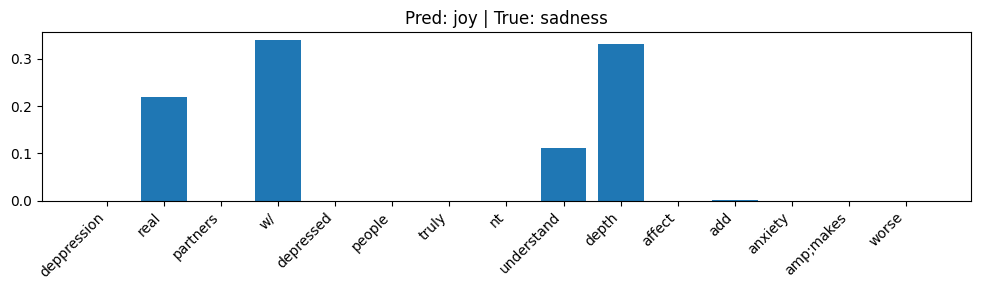

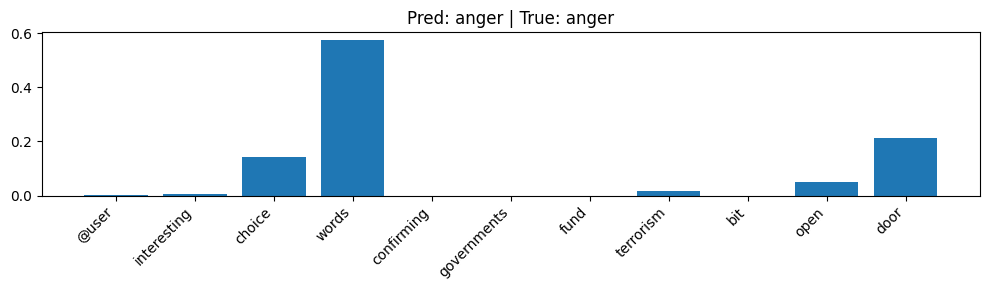

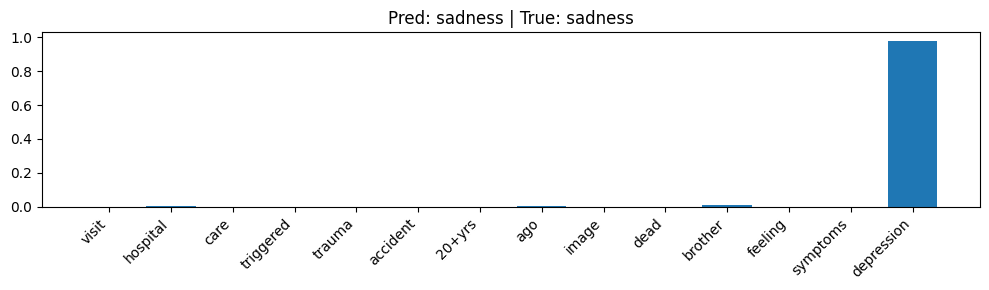

In [12]:
import matplotlib.pyplot as plt
mapping = {0: "anger", 1: "joy", 2: "optimism", 3: "sadness"}
for i in range(3):
    sentence, label = test_data[i]

    if len(sentence) == 0:
        continue

    sentence_in = prepare_sequence(sentence, word_to_ix, UNK_IDX)

    with torch.no_grad():
        output, attn_weights = model(sentence_in, return_attention=True)

    attn = attn_weights.squeeze().cpu().numpy()
    pred = torch.argmax(output, dim=1).item()

    plt.figure(figsize=(10, 3))
    plt.bar(range(len(sentence)), attn)
    plt.xticks(range(len(sentence)), sentence, rotation=45, ha="right")
    plt.title(f"Pred: {mapping[pred]} | True: {mapping[label]}")
    plt.tight_layout()
    plt.show()